# Dataset Loading 
Load your self-generated digits dataset from `dataset/labels.csv` and `dataset/images/*`.

In [77]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()  # coursework.ipynb is in /project
LABELS_CSV = PROJECT_DIR / 'dataset' / 'labels.csv'

df = pd.read_csv(LABELS_CSV)
df.head()

,filepath,label,writer_id,sheet_id,source_sheet,cell_index
0,dataset/images/0/ Khan_ 0_ sheet1_ 0.png,0,Khan,sheet1,Khan_0_sheet1.JPG,0
1,dataset/images/0/ Khan_ 0_ sheet1_ 1.png,0,Khan,sheet1,Khan_0_sheet1.JPG,1
2,dataset/images/0/ Khan_ 0_ sheet1_ 2.png,0,Khan,sheet1,Khan_0_sheet1.JPG,2
3,dataset/images/0/ Khan_ 0_ sheet1_ 3.png,0,Khan,sheet1,Khan_0_sheet1.JPG,3
4,dataset/images/0/ Khan_ 0_ sheet1_ 4.png,0,Khan,sheet1,Khan_0_sheet1.JPG,4


In [78]:
# Loading the dataset and listing the size and images per class
X_list ,y_list = [],[]
for row in df.itertuples(index=False):
    img_path = row.filepath
    img = Image.open(img_path).convert("L").resize((28,28))
    X_list.append(np.array(img,dtype=np.uint8))
    y_list.append(int(row.label))

X = np.stack(X_list)
y = np.array(y_list, dtype=np.int64)

print("Total dataset size: ", len(X))

unique, count = np.unique(y, return_counts=True)
print("Images per class:")
for u, c in zip(unique, count):
    print(f"Digit {u} : {c}")

Total dataset size:  1200
Images per class:
Digit 0 : 200
Digit 1 : 200
Digit 2 : 200
Digit 3 : 200
Digit 4 : 200
Digit 5 : 200


# Normalising the pixel values
To improve the numerical stability and ensuring consisten feature scaling.

In [79]:
# Normalising the pixel values
X_float = X.astype(np.float32) / 255.0
X_flat = X_float.reshape(len(X_float), -1)  # (N, 784)

print(X_float.dtype)



float32


# Data Split 
The Data split will be 80/20

The random seed is set to 42

In [80]:
# using sklean to split the train dataset
from sklearn.model_selection import train_test_split
import random

SEED = 42 # taking the usual number

random.seed(SEED)
np.random.seed(SEED)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
    shuffle=True
)
print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Random seed:", SEED)

Train size: 960
Test size: 240
Random seed: 42


# Traning Model

In [ ]:
# importing Logistic regression model and training it
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(
    # multi_class="multinomial",  getting warning that multiclass is deprecated and the default is multinomial so going to remove this for now
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
clf.fit(X_train, y_train)

# Predictions and Results and Evaluations

In [ ]:
y_pred = clf.predict(X_test)
probs = clf.predict_proba(X_test) # shape: (num_samples, num_classes)

In [ ]:
from sklearn.metrics import accuracy_score 
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")

Test accuracy: 0.6875


## Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=[0,1,2,3,4,5])
print(cm)

[[20  4  0  2 11  3]
 [ 0 35  0  3  2  0]
 [ 0  1 37  1  0  1]
 [ 2  2  0 28  3  5]
 [ 9  4  0  5 20  2]
 [ 5  0  0  5  5 25]]


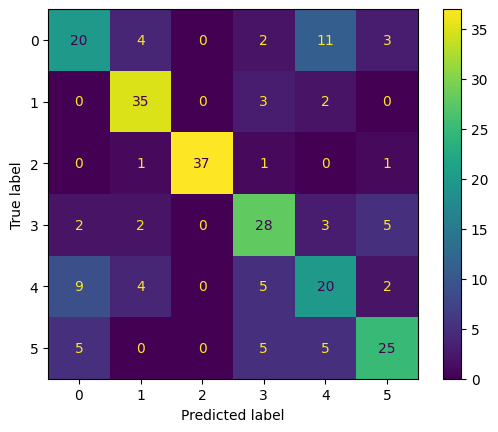

In [ ]:
# plotting the confusion matrix
import matplotlib.pyplot as plt
cm_display= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4,5])
cm_display.plot()
plt.show()

# Recall Score

In [ ]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred, average=None)


array([0.5  , 0.875, 0.925, 0.7  , 0.5  , 0.625])

In [ ]:
mis_idx = np.where(y_pred != y_test)[0]
mis_by_class = {i: [] for i in range(6)}  # 0–5

for idx in mis_idx:
    true_class = y_test[idx]
    
    if len(mis_by_class[true_class]) < 6:
        mis_by_class[true_class].append(idx)
    
for idx in range(0, 240, 40):
    cls = idx / 40
    print(f"\nClass {int(cls)} misclassified examples:")
    print("True:", y_test[idx])
    print("Pred:", y_pred[idx])
    print("Probabilities:", probs[idx])
    print()


Class 0 misclassified examples:
Index: 0
True: 0
Pred: 1
Probabilities: [0.02078433 0.60558064 0.0015874  0.19076715 0.0016943  0.17958618]


Class 1 misclassified examples:
Index: 40
True: 2
Pred: 2
Probabilities: [3.17431952e-03 1.38869557e-08 9.79532574e-01 1.28968807e-02
 1.09773991e-06 4.39511426e-03]


Class 2 misclassified examples:
Index: 80
True: 3
Pred: 4
Probabilities: [4.20210154e-02 1.75710837e-02 6.16548986e-04 2.28618859e-02
 8.33193361e-01 8.37361045e-02]


Class 3 misclassified examples:
Index: 120
True: 0
Pred: 4
Probabilities: [0.42103863 0.11599932 0.0008963  0.0195736  0.44165824 0.00083392]


Class 4 misclassified examples:
Index: 160
True: 0
Pred: 4
Probabilities: [1.74305088e-02 8.07624744e-04 5.85560236e-07 3.44995472e-03
 9.63930875e-01 1.43804512e-02]


Class 5 misclassified examples:
Index: 200
True: 2
Pred: 2
Probabilities: [2.86969928e-07 1.50902684e-08 9.99990995e-01 7.48246537e-06
 8.40669102e-07 3.79519521e-07]

